# 03 · Árbol de Decisión para detectar riesgo de abandono

**Proyecto:** JARVIS_SANGRON  
**Problema:** Predicción del riesgo de abandono estudiantil  
**Dataset:** OULAD — `studentInfo.csv`

## Pregunta que intenta responder el modelo

> **Con la información disponible de una inscripción, ¿podemos identificar si existe riesgo de abandono?**

La variable objetivo tiene dos resultados:

- **0 → No abandono**
- **1 → Abandono (`Withdrawn`)**

Un **Árbol de Decisión** puede entenderse como una secuencia de preguntas.
Cada pregunta divide los registros en grupos cada vez más específicos hasta llegar
a una predicción predominante.

Al final se compara este modelo con la **Regresión Logística** desarrollada en
`02_regresion_logistica.ipynb`.

> Para evitar utilizar los mismos datos para ajustar y evaluar el modelo, se trabaja con
> **Entrenamiento (70 %), Validación (15 %) y Prueba (15 %)**.

## Ruta de trabajo

1. Cargar y verificar los datos.
2. Definir qué significa abandono.
3. Preparar las variables que utilizará el modelo.
4. Separar los datos en **Entrenamiento / Validación / Prueba**.
5. Buscar una configuración adecuada del Árbol de Decisión.
6. Identificar qué variables utiliza más el modelo.
7. Traducir las primeras decisiones del árbol a preguntas comprensibles.
8. Seleccionar el punto de corte mediante el **Índice de Youden**.
9. Evaluar el resultado final sobre Prueba.
10. Comparar el Árbol de Decisión con la Regresión Logística.

## 1. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 777

## 2. Carga del dataset

Se utiliza `studentInfo.csv`, el mismo conjunto trabajado en las etapas anteriores.

La unidad de análisis es un **registro estudiante–módulo–presentación**.

In [2]:
df = pd.read_csv('../Data/studentInfo.csv')

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [3]:
print("Columnas:")
print(df.columns.tolist())

print("\nValores faltantes:")
display(df.isna().sum().to_frame('faltantes'))

Columnas:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Valores faltantes:


,faltantes
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


## 3. Variable objetivo

El resultado académico original se encuentra en `final_result`.

Para el problema de clasificación se construye:

- `abandono = 1` si `final_result == 'Withdrawn'`
- `abandono = 0` en cualquier otro resultado

`final_result` no se utiliza como variable explicativa porque contiene directamente
la información usada para construir el target. Incluirla produciría **data leakage**.

In [4]:
df['abandono'] = (df['final_result'] == 'Withdrawn').astype(int)

distribucion_target = (
    df['abandono']
    .value_counts()
    .sort_index()
    .rename(index={0: 'No abandono', 1: 'Abandono'})
    .to_frame('Registros')
)

distribucion_target['Porcentaje'] = (
    distribucion_target['Registros'] / len(df) * 100
).round(2)

display(distribucion_target)

,Registros,Porcentaje
abandono,,
No abandono,22437,68.84
Abandono,10156,31.16


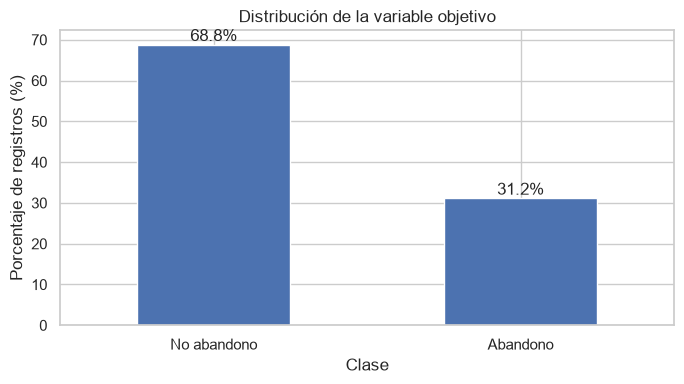

In [5]:
ax = distribucion_target['Porcentaje'].plot(
    kind='bar',
    figsize=(7, 4)
)

ax.set_title('Distribución de la variable objetivo')
ax.set_xlabel('Clase')
ax.set_ylabel('Porcentaje de registros (%)')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Punto de partida del problema

La tasa histórica de abandono es el **punto de referencia** del proyecto.

Como las clases no están equilibradas, la **Exactitud (Accuracy)** no debe
interpretarse por sí sola. Un modelo podría acertar muchos casos simplemente
prediciendo siempre la clase más frecuente y, aun así, ser poco útil para detectar
estudiantes que realmente abandonan.

In [6]:
tasa_abandono = df['abandono'].mean()
exactitud_mayoritaria = df['abandono'].value_counts(normalize=True).max()

print(f"Tasa histórica de abandono: {tasa_abandono:.2%}")
print(
    "Exactitud si siempre se predijera 'No abandono': "
    f"{exactitud_mayoritaria:.2%}"
)

# Se mantiene este alias para las comparaciones posteriores.
accuracy_mayoritaria = exactitud_mayoritaria

Tasa histórica de abandono: 31.16%
Exactitud si siempre se predijera 'No abandono': 68.84%


## 4. Variables explicativas

Se utilizan las diez variables disponibles consideradas en el planteamiento del proyecto:

- `code_module`
- `code_presentation`
- `gender`
- `region`
- `highest_education`
- `imd_band`
- `age_band`
- `num_of_prev_attempts`
- `studied_credits`
- `disability`

`id_student` se excluye porque es un identificador.

In [7]:
variables_modelo = [
    'code_module',
    'code_presentation',
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'num_of_prev_attempts',
    'studied_credits',
    'disability'
]

X = df[variables_modelo].copy()
y = df['abandono'].copy()

X['imd_band'] = X['imd_band'].fillna('Unknown')

print("Faltantes después del tratamiento:")
display(X.isna().sum().to_frame('faltantes'))

Faltantes después del tratamiento:


,faltantes
code_module,0
code_presentation,0
gender,0
region,0
highest_education,0
imd_band,0
age_band,0
num_of_prev_attempts,0
studied_credits,0
disability,0


### Codificación de variables categóricas

Los modelos de scikit-learn requieren entradas numéricas. Las variables categóricas
se transforman mediante **one-hot encoding**.

Se utiliza `drop_first=True` para evitar una categoría redundante por variable.

In [8]:
columnas_categoricas = X.select_dtypes(include='str').columns

X_modelo = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True,
    dtype=int
)

print("Dimensiones antes de codificar :", X.shape)
print("Dimensiones después de codificar:", X_modelo.shape)

display(X_modelo.head())

Dimensiones antes de codificar : (32593, 10)
Dimensiones después de codificar: (32593, 41)


,num_of_prev_attempts,studied_credits,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,disability_Y
0,0,240,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1
3,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


## 5. División en Entrenamiento / Validación / Prueba

Los datos se dividen en tres conjuntos:

- **70 % Entrenamiento:** para ajustar el modelo y buscar hiperparámetros.
- **15 % Validación:** para determinar el punto de corte con el Índice de Youden.
- **15 % Prueba:** para medir el desempeño final.

Se utiliza `stratify` para conservar aproximadamente la misma proporción de abandono
en los tres subconjuntos.

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_modelo,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

resumen_particion = pd.DataFrame({
    'Conjunto': ['Entrenamiento', 'Validación', 'Prueba'],
    'Registros': [len(X_train), len(X_val), len(X_test)],
    'Porcentaje': [
        len(X_train) / len(X_modelo) * 100,
        len(X_val) / len(X_modelo) * 100,
        len(X_test) / len(X_modelo) * 100
    ],
    'Tasa abandono': [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

display(resumen_particion.round(2))

,Conjunto,Registros,Porcentaje,Tasa abandono
0,Entrenamiento,22815,70.0,31.16
1,Validación,4889,15.0,31.15
2,Prueba,4889,15.0,31.17


## 6. Búsqueda de una configuración adecuada del árbol

Un árbol demasiado profundo puede memorizar particularidades del conjunto de entrenamiento.
Por ello se prueban distintas configuraciones mediante `GridSearchCV`.

Los parámetros evaluados son:

- **Profundidad máxima (`max_depth`)**: cuántos niveles puede alcanzar el árbol.
- **Mínimo para dividir (`min_samples_split`)**: cuántos registros necesita un nodo para dividirse.
- **Mínimo por hoja (`min_samples_leaf`)**: cuántos registros deben permanecer como mínimo en una hoja.

La búsqueda se realiza únicamente sobre **Entrenamiento** con validación cruzada de
5 particiones.

Como el problema presenta desbalance entre las clases, se utiliza **F1-score** como
criterio de selección de hiperparámetros.

In [10]:
# Búsqueda de hiperparámetros del Árbol de Decisión
# Se utiliza una grilla reducida para evitar miles de entrenamientos.

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20]
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)

grid_tree.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_tree.best_params_)

print(
    f"Mejor F1 promedio en validación cruzada: "
    f"{grid_tree.best_score_:.4f}"
)

Mejores hiperparámetros:
{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mejor F1 promedio en validación cruzada: 0.2959


## 7. Modelo de Árbol de Decisión

Se utiliza directamente el mejor modelo encontrado por `GridSearchCV`.

In [11]:
modelo_arbol = grid_tree.best_estimator_

print(modelo_arbol)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=777)


## 8. ¿Qué información utiliza más el modelo?

El Árbol de Decisión no solo produce una clasificación. También permite observar
qué variables fueron más útiles para separar grupos con diferente comportamiento de abandono.

### Importancia de las variables

Una importancia alta significa que esa variable participó de forma relevante en las
divisiones internas del árbol.

> **No implica causalidad.** Una variable importante ayuda a diferenciar grupos dentro
> del modelo, pero no demuestra que provoque el abandono.

In [12]:
# Traducciones utilizadas únicamente para presentar los resultados de forma legible.
traducciones_exactas = {
    'num_of_prev_attempts': 'Intentos previos',
    'studied_credits': 'Créditos matriculados',
    'gender_M': 'Género = Hombre',
    'disability_Y': 'Discapacidad = Sí',
    'age_band_35-55': 'Edad = 35 a 55 años',
    'age_band_55<=': 'Edad = 55 años o más',
    'highest_education_HE Qualification': 'Educación previa = Educación superior',
    'highest_education_Lower Than A Level': 'Educación previa = Inferior a A Level',
    'highest_education_No Formal quals': 'Educación previa = Sin titulación formal',
    'highest_education_Post Graduate Qualification': 'Educación previa = Posgrado'
}

traducciones_regiones = {
    'East Midlands Region': 'East Midlands',
    'Ireland': 'Irlanda',
    'London Region': 'Londres',
    'North Region': 'Norte',
    'North Western Region': 'Noroeste',
    'Scotland': 'Escocia',
    'South East Region': 'Sudeste',
    'South Region': 'Sur',
    'South West Region': 'Suroeste',
    'Wales': 'Gales',
    'West Midlands Region': 'West Midlands',
    'Yorkshire Region': 'Yorkshire'
}

def nombre_variable_es(nombre):
    if nombre in traducciones_exactas:
        return traducciones_exactas[nombre]

    if nombre.startswith('code_module_'):
        return 'Módulo = ' + nombre.replace('code_module_', '')

    if nombre.startswith('code_presentation_'):
        return 'Presentación = ' + nombre.replace('code_presentation_', '')

    if nombre.startswith('region_'):
        region = nombre.replace('region_', '')
        return 'Región = ' + traducciones_regiones.get(region, region)

    if nombre.startswith('imd_band_'):
        banda = nombre.replace('imd_band_', '')
        if banda == 'Unknown':
            banda = 'Sin dato'
        return 'Nivel socioeconómico (IMD) = ' + banda

    return nombre.replace('_', ' ').capitalize()

nombres_variables_es = [nombre_variable_es(c) for c in X_train.columns]

importancias = pd.DataFrame({
    'Variable original': X_train.columns,
    'Variable': nombres_variables_es,
    'Importancia (%)': modelo_arbol.feature_importances_ * 100
})

importancias = (
    importancias
    .sort_values('Importancia (%)', ascending=False)
    .reset_index(drop=True)
)

display(importancias[['Variable', 'Importancia (%)']].head(15).round(2))

,Variable,Importancia (%)
0,Créditos matriculados,34.33
1,Módulo = CCC,9.88
2,Educación previa = Inferior a A Level,8.78
3,Módulo = GGG,7.38
4,Presentación = 2014J,4.55
5,Módulo = DDD,3.89
6,Región = Escocia,3.06
7,Género = Hombre,2.91
8,Discapacidad = Sí,2.66
9,Nivel socioeconómico (IMD) = Sin dato,1.88


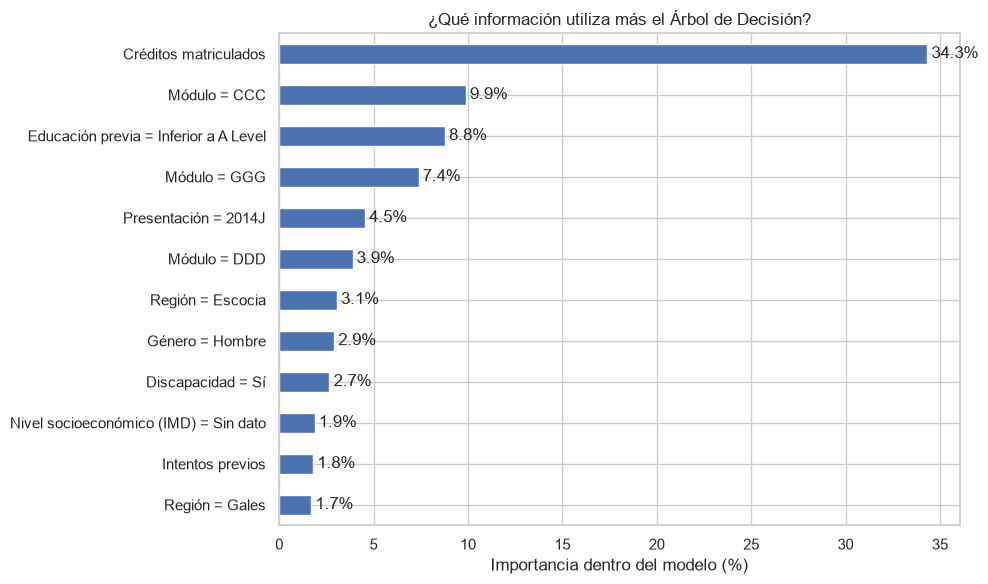

In [13]:
top_importancias = importancias.head(12).sort_values(
    'Importancia (%)',
    ascending=True
)

ax = top_importancias.plot(
    x='Variable',
    y='Importancia (%)',
    kind='barh',
    figsize=(10, 6),
    legend=False
)

ax.set_title('¿Qué información utiliza más el Árbol de Decisión?')
ax.set_xlabel('Importancia dentro del modelo (%)')
ax.set_ylabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

### Cómo leer el Árbol de Decisión

La visualización siguiente muestra únicamente las **primeras decisiones** del modelo.

Cada recuadro responde cuatro preguntas:

1. **¿Qué pregunta está haciendo el modelo?**
2. **¿Qué porcentaje de registros llega hasta ese punto?**
3. **¿Qué proporción corresponde a abandono y no abandono?**
4. **¿Qué resultado predomina en ese grupo?**

### Regla para seguir las ramas

- **SÍ → rama izquierda**
- **NO → rama derecha**

Por ejemplo:

> **¿Tiene 82 créditos matriculados o menos?**

Si la respuesta es **Sí**, se continúa hacia la izquierda.  
Si la respuesta es **No**, se continúa hacia la derecha.

El objetivo de este diagrama no es mostrar todo el árbol completo, sino hacer
comprensibles sus primeras reglas de decisión.

In [14]:
from sklearn.tree import _tree

def es_variable_dummy(nombre):
    prefijos = (
        'code_module_',
        'code_presentation_',
        'gender_',
        'region_',
        'highest_education_',
        'imd_band_',
        'age_band_',
        'disability_'
    )
    return nombre.startswith(prefijos)


def pregunta_nodo(nombre_original, corte):
    """
    Convierte una condición interna del árbol en una pregunta legible.
    """
    nombre = nombre_variable_es(nombre_original)

    if es_variable_dummy(nombre_original) and abs(corte - 0.5) < 0.01:
        return f"¿{nombre}?"

    if nombre_original == 'studied_credits':
        return f"¿Tiene {corte:.0f} créditos matriculados o menos?"

    if nombre_original == 'num_of_prev_attempts':
        return f"¿Tiene {corte:.0f} intentos previos o menos?"

    return f"¿{nombre} ≤ {corte:.1f}?"

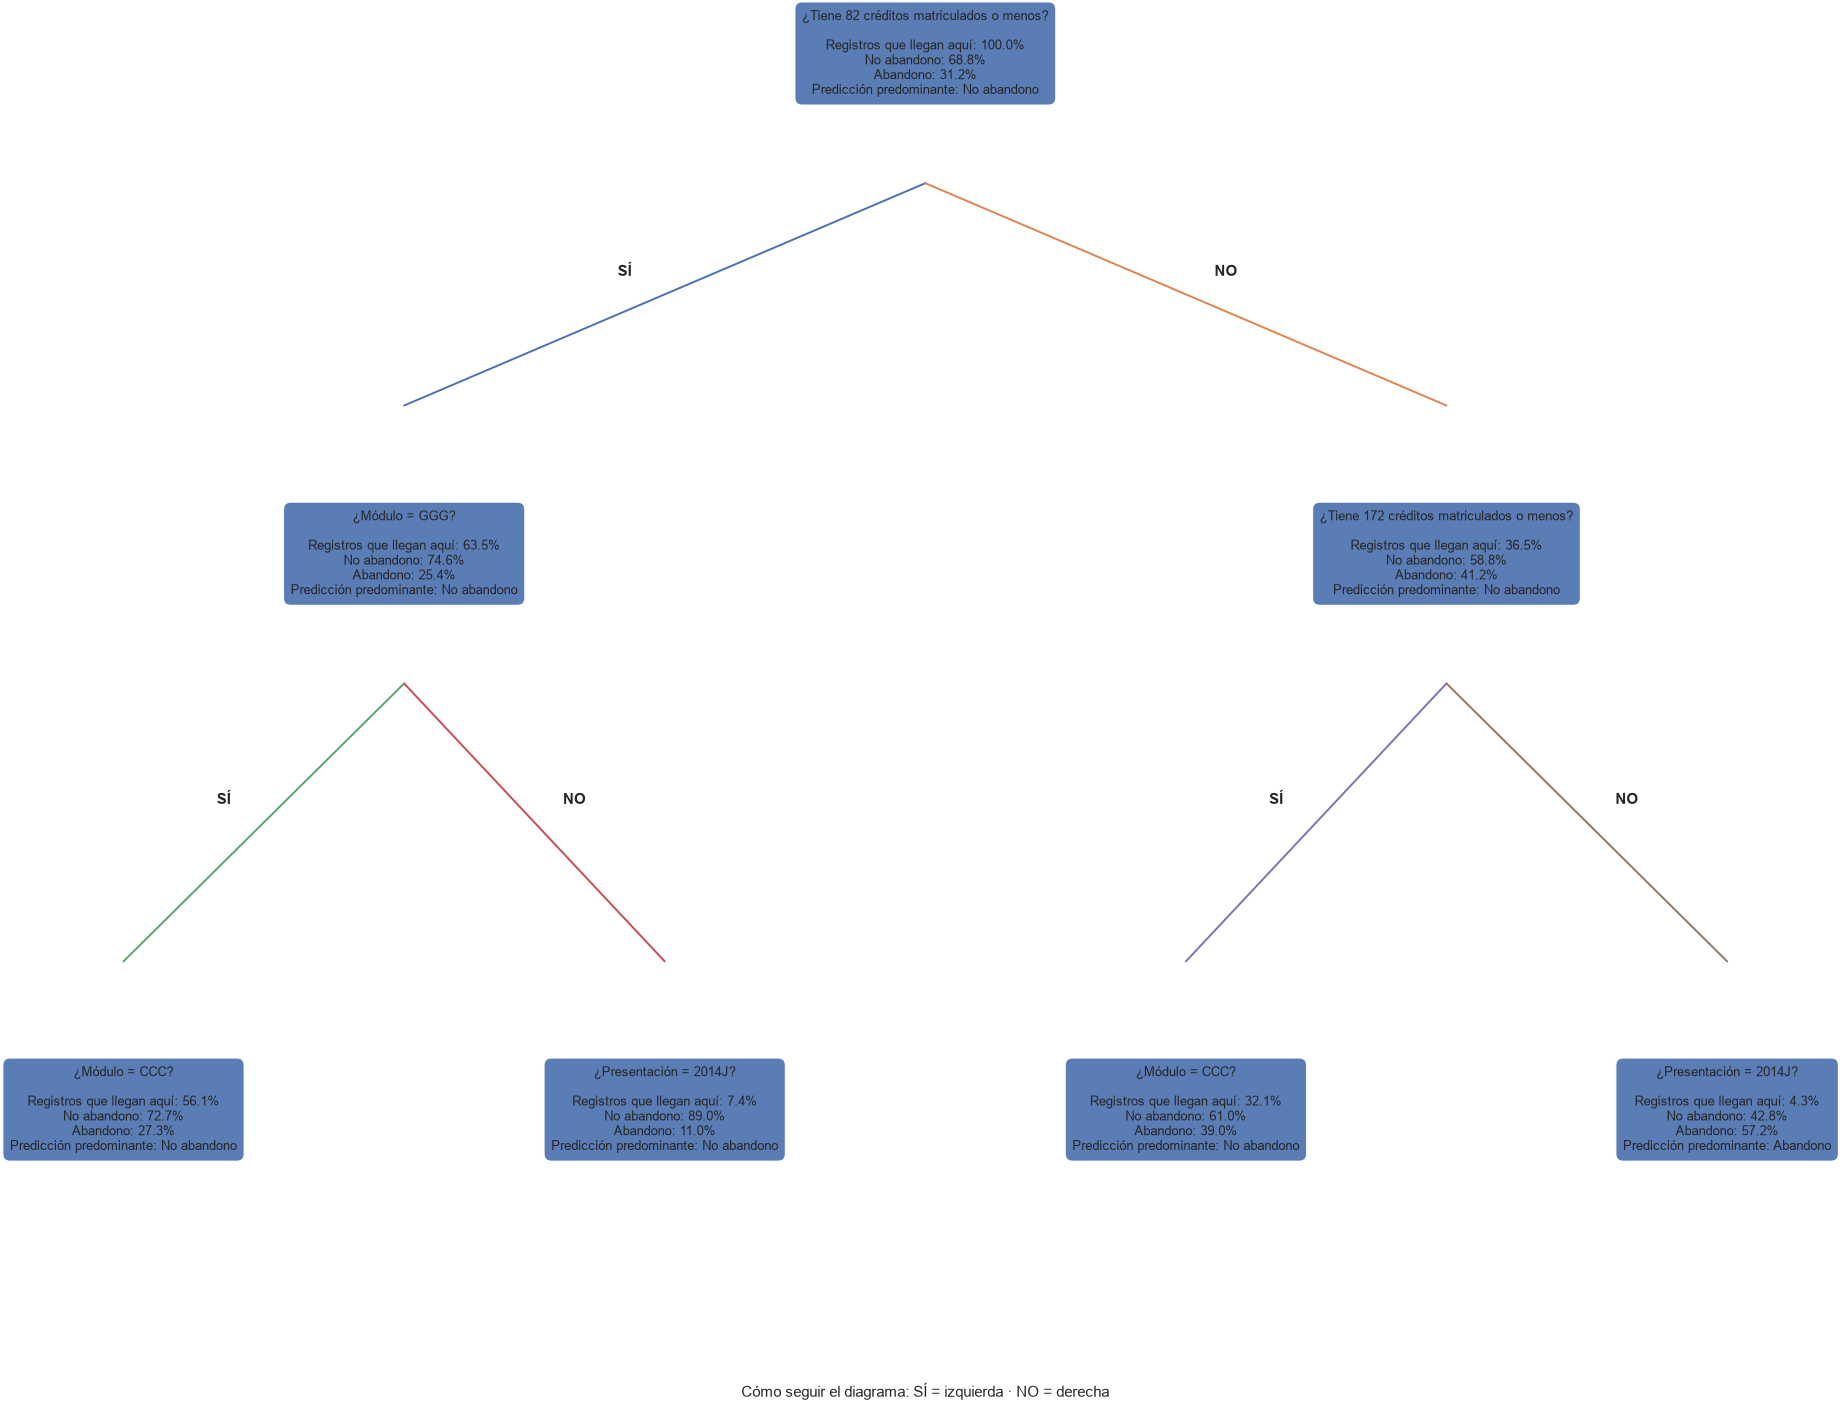

In [30]:
def dibujar_arbol_amigable(modelo, columnas, profundidad_mostrada=2):
    """
    Muestra las primeras decisiones del árbol en formato pedagógico.
    La rama izquierda representa SÍ y la rama derecha representa NO.
    """
    estructura = modelo.tree_
    total_raiz = estructura.weighted_n_node_samples[0]

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis('off')

    # Más espacio vertical para evitar superposición con el título.
    posiciones = {
        (0, 0): (0.50, 0.76),

        (1, 0): (0.24, 0.49),
        (1, 1): (0.76, 0.49),

        (2, 0): (0.10, 0.19),
        (2, 1): (0.37, 0.19),
        (2, 2): (0.63, 0.19),
        (2, 3): (0.90, 0.19),
    }

    nodos_por_nivel = {0: [0]}

    for nivel in range(profundidad_mostrada):
        actuales = nodos_por_nivel.get(nivel, [])
        siguientes = []

        for nodo in actuales:
            if nodo is None or estructura.feature[nodo] == _tree.TREE_UNDEFINED:
                siguientes.extend([None, None])
                continue

            siguientes.append(estructura.children_left[nodo])
            siguientes.append(estructura.children_right[nodo])

        nodos_por_nivel[nivel + 1] = siguientes

    # Conexiones y etiquetas SÍ / NO
    for nivel in range(profundidad_mostrada):
        actuales = nodos_por_nivel.get(nivel, [])

        for indice, nodo in enumerate(actuales):
            if nodo is None or estructura.feature[nodo] == _tree.TREE_UNDEFINED:
                continue

            x1, y1 = posiciones[(nivel, indice)]

            idx_izq = indice * 2
            idx_der = indice * 2 + 1

            if (nivel + 1, idx_izq) in posiciones:
                x2, y2 = posiciones[(nivel + 1, idx_izq)]
                ax.plot([x1, x2], [y1 - 0.07, y2 + 0.08], linewidth=1.4)
                ax.text(
                    (x1 + x2) / 2 - 0.02,
                    (y1 + y2) / 2 + 0.015,
                    "SÍ",
                    fontsize=11,
                    fontweight='bold',
                    ha='center'
                )

            if (nivel + 1, idx_der) in posiciones:
                x2, y2 = posiciones[(nivel + 1, idx_der)]
                ax.plot([x1, x2], [y1 - 0.07, y2 + 0.08], linewidth=1.4)
                ax.text(
                    (x1 + x2) / 2 + 0.02,
                    (y1 + y2) / 2 + 0.015,
                    "NO",
                    fontsize=11,
                    fontweight='bold',
                    ha='center'
                )

    # Cuadros
    for nivel, lista in nodos_por_nivel.items():
        if nivel > profundidad_mostrada:
            continue

        for indice, nodo in enumerate(lista):
            if nodo is None or (nivel, indice) not in posiciones:
                continue

            x, y = posiciones[(nivel, indice)]

            valores = estructura.value[nodo][0]
            total = valores.sum()
            proporciones = valores / total if total else valores

            porcentaje_registros = (
                estructura.weighted_n_node_samples[nodo] / total_raiz * 100
            )

            clase_predicha = modelo.classes_[np.argmax(valores)]
            clase_txt = "Abandono" if clase_predicha == 1 else "No abandono"

            if estructura.feature[nodo] != _tree.TREE_UNDEFINED:
                idx_var = estructura.feature[nodo]
                nombre_original = columnas[idx_var]
                corte = estructura.threshold[nodo]
                pregunta = pregunta_nodo(nombre_original, corte)
            else:
                pregunta = "Decisión final"

            texto = (
                f"{pregunta}\n\n"
                f"Registros que llegan aquí: {porcentaje_registros:.1f}%\n"
                f"No abandono: {proporciones[0] * 100:.1f}%\n"
                f"Abandono: {proporciones[1] * 100:.1f}%\n"
                f"Predicción predominante: {clase_txt}"
            )

            ax.text(
                x,
                y,
                texto,
                ha='center',
                va='center',
                fontsize=9.5,
                bbox=dict(
                    boxstyle='round,pad=0.55',
                    alpha=0.92
                )
            )

    fig.suptitle(
        "",
        fontsize=16,
        y=0.98
    )

    ax.text(
        0.50,
        0.035,
        "Cómo seguir el diagrama: SÍ = izquierda · NO = derecha",
        ha='center',
        fontsize=11
    )

    plt.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()


dibujar_arbol_amigable(
    modelo_arbol,
    X_train.columns.tolist(),
    profundidad_mostrada=2
)

### Las mismas decisiones explicadas como una ruta

El diagrama ayuda a ver la estructura general, pero también puede leerse como una
secuencia de preguntas.

La siguiente celda imprime las primeras decisiones en formato textual para facilitar
su explicación durante una exposición.

In [16]:
def mostrar_arbol_legible(modelo, columnas, max_niveles=2):
    estructura = modelo.tree_

    def recorrer(nodo, nivel=0, respuesta='INICIO'):
        sangria = '    ' * nivel

        valores = estructura.value[nodo][0]
        total = valores.sum()
        proporciones = valores / total if total else valores

        if estructura.feature[nodo] == _tree.TREE_UNDEFINED:
            clase = modelo.classes_[np.argmax(valores)]
            clase_txt = 'Abandono' if clase == 1 else 'No abandono'

            print(
                f"{sangria}{respuesta} → Predicción predominante: {clase_txt} "
                f"| Abandono en el grupo: {proporciones[1]:.1%}"
            )
            return

        idx_var = estructura.feature[nodo]
        nombre_original = columnas[idx_var]
        corte = estructura.threshold[nodo]
        pregunta = pregunta_nodo(nombre_original, corte)

        if nivel == 0:
            print(pregunta)
            print(
                f"Grupo inicial → No abandono: {proporciones[0]:.1%} | "
                f"Abandono: {proporciones[1]:.1%}"
            )
        else:
            print(f"{sangria}{respuesta} → {pregunta}")
            print(
                f"{sangria}     Grupo → No abandono: {proporciones[0]:.1%} | "
                f"Abandono: {proporciones[1]:.1%}"
            )

        if nivel < max_niveles:
            recorrer(
                estructura.children_left[nodo],
                nivel + 1,
                'SÍ'
            )
            recorrer(
                estructura.children_right[nodo],
                nivel + 1,
                'NO'
            )

    print("LECTURA GUIADA DE LAS PRIMERAS DECISIONES")
    print("-----------------------------------------")
    print("SÍ = rama izquierda | NO = rama derecha\n")

    recorrer(0)


mostrar_arbol_legible(
    modelo_arbol,
    X_train.columns.tolist(),
    max_niveles=2
)

LECTURA GUIADA DE LAS PRIMERAS DECISIONES
-----------------------------------------
SÍ = rama izquierda | NO = rama derecha

¿Tiene 82 créditos matriculados o menos?
Grupo inicial → No abandono: 68.8% | Abandono: 31.2%
    SÍ → ¿Módulo = GGG?
         Grupo → No abandono: 74.6% | Abandono: 25.4%
        SÍ → ¿Módulo = CCC?
             Grupo → No abandono: 72.7% | Abandono: 27.3%
        NO → ¿Presentación = 2014J?
             Grupo → No abandono: 89.0% | Abandono: 11.0%
    NO → ¿Tiene 172 créditos matriculados o menos?
         Grupo → No abandono: 58.8% | Abandono: 41.2%
        SÍ → ¿Módulo = CCC?
             Grupo → No abandono: 61.0% | Abandono: 39.0%
        NO → ¿Presentación = 2014J?
             Grupo → No abandono: 42.8% | Abandono: 57.2%


## 9. Selección del punto de corte mediante Índice de Youden

El Árbol de Decisión genera una **probabilidad estimada de abandono**.

Para decidir desde qué probabilidad se activa una alerta se utiliza el
**Índice de Youden**.

Su expresión es:

**Youden = Sensibilidad + Especificidad − 1**

También puede expresarse como:

**Youden = TPR − FPR**

donde:

- **Sensibilidad (TPR):** proporción de abandonos reales detectados.
- **Especificidad:** proporción de no abandonos identificados correctamente.
- **FPR:** proporción de no abandonos clasificados incorrectamente como abandono.

El punto de corte seleccionado es el que obtiene el **mayor Índice de Youden**.

> El cálculo se realiza únicamente con **Validación**. Después, el punto de corte queda
> fijo y se utiliza sobre **Prueba** para la evaluación final.

In [17]:
# Probabilidades estimadas de abandono en VALIDACIÓN
prob_val = modelo_arbol.predict_proba(X_val)[:, 1]

# Curva ROC
fpr_val, tpr_val, umbrales_val = roc_curve(
    y_val,
    prob_val
)

# Índice de Youden = TPR - FPR
indice_youden = tpr_val - fpr_val

# Posición con el mayor índice
pos_optima = np.argmax(indice_youden)

# Punto de corte elegido
umbral_final = float(umbrales_val[pos_optima])

# Métricas asociadas al corte
sensibilidad_optima = float(tpr_val[pos_optima])
especificidad_optima = float(1 - fpr_val[pos_optima])
youden_optimo = float(indice_youden[pos_optima])

resultado_youden = pd.DataFrame({
    'Indicador': [
        'Punto de corte',
        'Sensibilidad',
        'Especificidad',
        'Índice de Youden'
    ],
    'Valor': [
        umbral_final,
        sensibilidad_optima,
        especificidad_optima,
        youden_optimo
    ]
})

print("PUNTO DE CORTE SEGÚN ÍNDICE DE YOUDEN")
print("--------------------------------------")
display(resultado_youden.style.format({'Valor': '{:.4f}'}))

print(
    f"Interpretación: desde una probabilidad estimada de "
    f"{umbral_final:.1%}, el modelo genera una alerta de posible abandono."
)

PUNTO DE CORTE SEGÚN ÍNDICE DE YOUDEN
--------------------------------------


,Indicador,Valor
0,Punto de corte,0.3226
1,Sensibilidad,0.5686
2,Especificidad,0.6509
3,Índice de Youden,0.2195


Interpretación: desde una probabilidad estimada de 32.3%, el modelo genera una alerta de posible abandono.


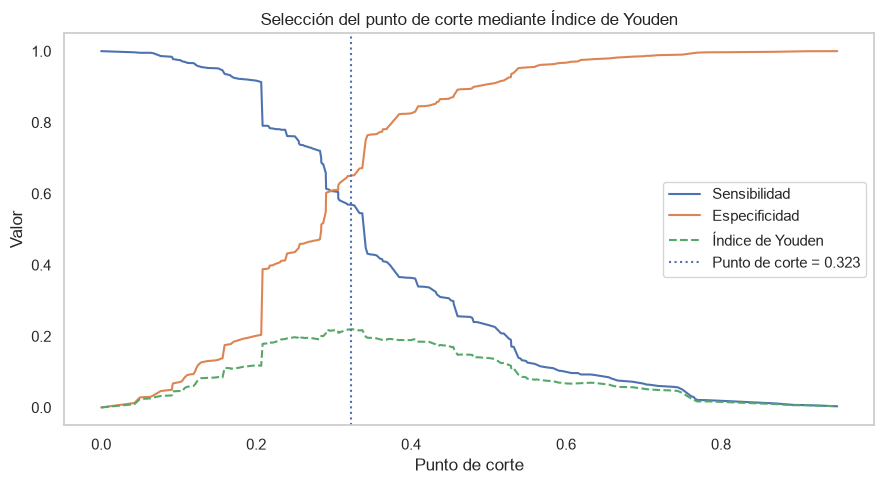

In [18]:
# Se omite el primer umbral si es infinito para que la gráfica sea legible.
mascara_finita = np.isfinite(umbrales_val)

umbrales_graf = umbrales_val[mascara_finita]
sensibilidad_graf = tpr_val[mascara_finita]
especificidad_graf = 1 - fpr_val[mascara_finita]
youden_graf = indice_youden[mascara_finita]

orden = np.argsort(umbrales_graf)

plt.figure(figsize=(9, 5))

plt.plot(
    umbrales_graf[orden],
    sensibilidad_graf[orden],
    label='Sensibilidad'
)

plt.plot(
    umbrales_graf[orden],
    especificidad_graf[orden],
    label='Especificidad'
)

plt.plot(
    umbrales_graf[orden],
    youden_graf[orden],
    linestyle='--',
    label='Índice de Youden'
)

plt.axvline(
    umbral_final,
    linestyle=':',
    label=f'Punto de corte = {umbral_final:.3f}'
)

plt.xlabel('Punto de corte')
plt.ylabel('Valor')
plt.title('Selección del punto de corte mediante Índice de Youden')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 10. Evaluación final sobre Prueba

Antes de analizar los resultados:

| Métrica | Interpretación en este proyecto |
|---|---|
| **Exactitud (Accuracy)** | De todos los registros, qué proporción se clasificó correctamente. |
| **Precisión** | De todas las alertas generadas, qué proporción correspondía realmente a abandono. |
| **Sensibilidad (Recall)** | De todos los abandonos reales, qué proporción logró detectar el modelo. |
| **Especificidad** | De todos los no abandonos reales, qué proporción identificó correctamente el modelo. |
| **F1-score** | Resume el equilibrio entre Precisión y Sensibilidad. |
| **AUC-ROC** | Evalúa la capacidad general del modelo para separar ambas clases a distintos cortes. |

Para una alerta temprana, la **Sensibilidad** es especialmente importante, pero debe
analizarse junto con la **Precisión**, la **Especificidad**, el **F1-score** y las
falsas alertas.

El conjunto de **Prueba** se utiliza solamente para esta evaluación final.

In [19]:
prob_test = modelo_arbol.predict_proba(X_test)[:, 1]
pred_test = (prob_test >= umbral_final).astype(int)

exactitud_arbol = accuracy_score(y_test, pred_test)
precision_arbol = precision_score(y_test, pred_test, zero_division=0)
sensibilidad_arbol = recall_score(y_test, pred_test, zero_division=0)
f1_arbol = f1_score(y_test, pred_test, zero_division=0)
auc_arbol = roc_auc_score(y_test, prob_test)

matriz_temporal = confusion_matrix(y_test, pred_test)
tn_tmp, fp_tmp, fn_tmp, tp_tmp = matriz_temporal.ravel()
especificidad_arbol = tn_tmp / (tn_tmp + fp_tmp)

# Alias para mantener compatibilidad con otras celdas.
accuracy_arbol = exactitud_arbol
recall_arbol = sensibilidad_arbol

metricas_arbol = pd.DataFrame({
    'Métrica': [
        'Exactitud (Accuracy)',
        'Precisión',
        'Sensibilidad (Recall)',
        'Especificidad',
        'F1-score',
        'AUC-ROC'
    ],
    'Valor': [
        exactitud_arbol,
        precision_arbol,
        sensibilidad_arbol,
        especificidad_arbol,
        f1_arbol,
        auc_arbol
    ]
})

print(f"Punto de corte aplicado en Prueba: {umbral_final:.4f}")
display(metricas_arbol.style.format({'Valor': '{:.4f}'}))

Punto de corte aplicado en Prueba: 0.3226


,Métrica,Valor
0,Exactitud (Accuracy),0.6314
1,Precisión,0.4304
2,Sensibilidad (Recall),0.5643
3,Especificidad,0.6618
4,F1-score,0.4884
5,AUC-ROC,0.6439


### ¿A cuántos estudiantes detectó realmente?

La matriz de confusión traduce el resultado a cuatro situaciones:

| Situación | Interpretación |
|---|---|
| **No abandono detectado correctamente** | No abandonó y el modelo no generó alerta. |
| **Falsa alerta** | No abandonó, pero el modelo generó una alerta. |
| **Abandono no detectado** | Abandonó, pero el modelo no lo detectó. |
| **Abandono detectado correctamente** | Abandonó y el modelo sí generó la alerta. |

En un sistema preventivo, los **abandonos no detectados** son especialmente importantes,
porque representan estudiantes que no habrían recibido una alerta.

In [20]:
matriz = confusion_matrix(y_test, pred_test)

tn, fp, fn, tp = matriz.ravel()
total_abandonos_reales = tp + fn
total_no_abandonos = tn + fp

print("LECTURA DE LA MATRIZ DE CONFUSIÓN")
print("----------------------------------")
print(f"✓ No abandono detectado correctamente : {tn}")
print(f"⚠ Falsas alertas                      : {fp}")
print(f"✗ Abandonos que el modelo no detectó  : {fn}")
print(f"✓ Abandonos detectados correctamente  : {tp}")

print(
    f"\nDe {total_abandonos_reales} abandonos reales, "
    f"el modelo detectó {tp} ({tp / total_abandonos_reales:.1%})."
)

print(
    f"De {total_no_abandonos} casos sin abandono, "
    f"generó {fp} falsas alertas ({fp / total_no_abandonos:.1%})."
)

LECTURA DE LA MATRIZ DE CONFUSIÓN
----------------------------------
✓ No abandono detectado correctamente : 2227
⚠ Falsas alertas                      : 1138
✗ Abandonos que el modelo no detectó  : 664
✓ Abandonos detectados correctamente  : 860

De 1524 abandonos reales, el modelo detectó 860 (56.4%).
De 3365 casos sin abandono, generó 1138 falsas alertas (33.8%).


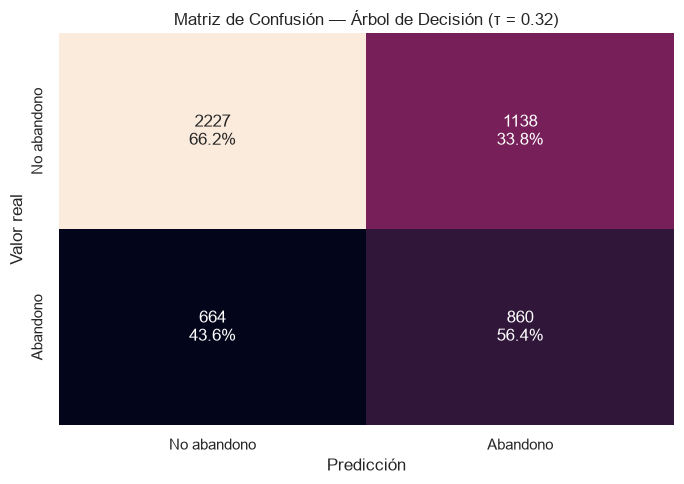

In [21]:
porcentajes = matriz / matriz.sum(axis=1, keepdims=True) * 100

anotaciones = np.empty_like(matriz, dtype=object)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        anotaciones[i, j] = f"{matriz[i, j]}\n{porcentajes[i, j]:.1f}%"

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz,
    annot=anotaciones,
    fmt='',
    cbar=False,
    xticklabels=['No abandono', 'Abandono'],
    yticklabels=['No abandono', 'Abandono']
)

plt.title(f'Matriz de Confusión — Árbol de Decisión (τ = {umbral_final:.2f})')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

In [22]:
reporte = classification_report(
    y_test,
    pred_test,
    target_names=['No abandono', 'Abandono'],
    zero_division=0,
    output_dict=True
)

reporte_es = pd.DataFrame({
    'Clase': ['No abandono', 'Abandono'],
    'Precisión': [
        reporte['No abandono']['precision'],
        reporte['Abandono']['precision']
    ],
    'Sensibilidad (Recall)': [
        reporte['No abandono']['recall'],
        reporte['Abandono']['recall']
    ],
    'F1-score': [
        reporte['No abandono']['f1-score'],
        reporte['Abandono']['f1-score']
    ],
    'Casos reales': [
        int(reporte['No abandono']['support']),
        int(reporte['Abandono']['support'])
    ]
})

display(
    reporte_es.style.format({
        'Precisión': '{:.4f}',
        'Sensibilidad (Recall)': '{:.4f}',
        'F1-score': '{:.4f}'
    })
)

,Clase,Precisión,Sensibilidad (Recall),F1-score,Casos reales
0,No abandono,0.7703,0.6618,0.7120,3365
1,Abandono,0.4304,0.5643,0.4884,1524


### Curva ROC

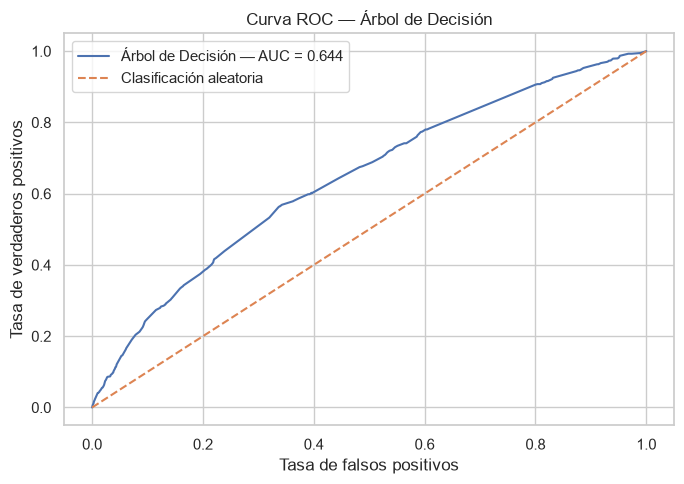

In [23]:
fpr, tpr, _ = roc_curve(y_test, prob_test)
auc_arbol = roc_auc_score(y_test, prob_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Árbol de Decisión — AUC = {auc_arbol:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Clasificación aleatoria')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — Árbol de Decisión')
plt.legend()
plt.tight_layout()
plt.show()

### Curva Precisión–Sensibilidad (Precision–Recall)

Esta curva muestra el intercambio entre:

- **Precisión:** qué tan confiables son las alertas.
- **Sensibilidad:** cuántos abandonos reales logramos detectar.

Cuando intentamos detectar más abandonos, normalmente aumenta también la cantidad
de falsas alertas.

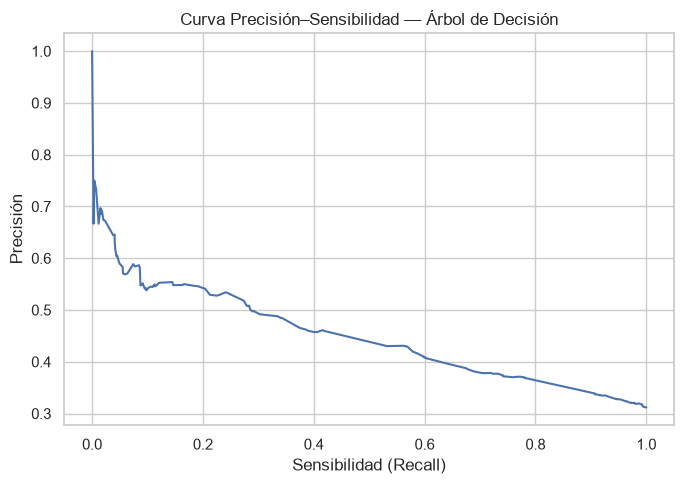

In [24]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, prob_test)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve)

plt.xlabel('Sensibilidad (Recall)')
plt.ylabel('Precisión')
plt.title('Curva Precisión–Sensibilidad — Árbol de Decisión')
plt.tight_layout()
plt.show()

## 11. Comparación con la línea base y los criterios del proyecto

Se utilizan tres referencias:

- **Línea base del negocio:** tasa histórica de abandono.
- **Línea base de clasificación:** qué ocurriría si siempre se predijera la clase mayoritaria.
- **Árbol de Decisión:** desempeño final sobre el conjunto de Prueba.

Los criterios de éxito técnico definidos para JARVIS_SANGRON son:

- **Sensibilidad (Recall) ≥ 0.75**
- **F1-score ≥ 0.70**

Por tanto, una Exactitud aparentemente alta no es suficiente para considerar exitoso al modelo.

In [25]:
exactitud_arbol = accuracy_score(y_test, pred_test)
precision_arbol = precision_score(y_test, pred_test, zero_division=0)
sensibilidad_arbol = recall_score(y_test, pred_test, zero_division=0)
f1_arbol = f1_score(y_test, pred_test, zero_division=0)
auc_arbol = roc_auc_score(y_test, prob_test)

matriz_aux = confusion_matrix(y_test, pred_test)
tn_aux, fp_aux, fn_aux, tp_aux = matriz_aux.ravel()
especificidad_arbol = tn_aux / (tn_aux + fp_aux)

accuracy_arbol = exactitud_arbol
recall_arbol = sensibilidad_arbol

resumen_modelo = pd.DataFrame({
    'Indicador': [
        'Tasa histórica de abandono',
        "Exactitud prediciendo siempre 'No abandono'",
        'Exactitud del Árbol',
        'Precisión de abandono',
        'Sensibilidad de abandono',
        'Especificidad',
        'F1-score de abandono',
        'AUC-ROC'
    ],
    'Valor': [
        tasa_abandono,
        accuracy_mayoritaria,
        exactitud_arbol,
        precision_arbol,
        sensibilidad_arbol,
        especificidad_arbol,
        f1_arbol,
        auc_arbol
    ]
})

display(resumen_modelo.style.format({'Valor': '{:.4f}'}))

meta_sensibilidad = 0.75
meta_f1 = 0.70

print("CRITERIOS DE ÉXITO TÉCNICO")
print("----------------------------")
print(
    f"Sensibilidad obtenida : {sensibilidad_arbol:.4f} "
    f"| Meta: {meta_sensibilidad:.2f}"
)
print(
    f"F1-score obtenido     : {f1_arbol:.4f} "
    f"| Meta: {meta_f1:.2f}"
)

if sensibilidad_arbol >= meta_sensibilidad:
    print("✓ Se alcanza la meta de Sensibilidad.")
else:
    print("✗ Todavía no se alcanza la meta de Sensibilidad.")

if f1_arbol >= meta_f1:
    print("✓ Se alcanza la meta de F1-score.")
else:
    print("✗ Todavía no se alcanza la meta de F1-score.")

,Indicador,Valor
0,Tasa histórica de abandono,0.3116
1,Exactitud prediciendo siempre 'No abandono',0.6884
2,Exactitud del Árbol,0.6314
3,Precisión de abandono,0.4304
4,Sensibilidad de abandono,0.5643
5,Especificidad,0.6618
6,F1-score de abandono,0.4884
7,AUC-ROC,0.6439


CRITERIOS DE ÉXITO TÉCNICO
----------------------------
Sensibilidad obtenida : 0.5643 | Meta: 0.75
F1-score obtenido     : 0.4884 | Meta: 0.70
✗ Todavía no se alcanza la meta de Sensibilidad.
✗ Todavía no se alcanza la meta de F1-score.


## 12. Comparación con Regresión Logística

Ambos modelos intentan detectar abandono, pero utilizan mecanismos diferentes:

- **Regresión Logística:** estima la probabilidad mediante una combinación matemática de variables.
- **Árbol de Decisión:** separa los registros mediante una secuencia de preguntas.

Se comparan:

- Exactitud
- Precisión
- Sensibilidad
- F1-score
- AUC-ROC

> **Nota metodológica:** en este notebook, el Árbol de Decisión utiliza el punto de corte
> seleccionado mediante **Índice de Youden** sobre Validación. Los valores de Regresión
> Logística corresponden a la evaluación final registrada en `02_regresion_logistica.ipynb`.
> Si se desea una comparación estrictamente homogénea del criterio de corte, el mismo
> procedimiento de Youden debe aplicarse también a la Regresión Logística.

In [26]:
# Resultados finales obtenidos previamente en 02_regresion_logistica.ipynb.
metricas_logit = {
    'Exactitud': 0.5639,
    'Precisión': 0.3928,
    'Sensibilidad': 0.7310,
    'F1-score': 0.5110,
    'AUC-ROC': 0.6730
}

comparacion_modelos = pd.DataFrame({
    'Métrica': [
        'Exactitud',
        'Precisión',
        'Sensibilidad (Recall)',
        'F1-score',
        'AUC-ROC'
    ],
    'Regresión Logística': [
        metricas_logit['Exactitud'],
        metricas_logit['Precisión'],
        metricas_logit['Sensibilidad'],
        metricas_logit['F1-score'],
        metricas_logit['AUC-ROC']
    ],
    'Árbol de Decisión': [
        exactitud_arbol,
        precision_arbol,
        sensibilidad_arbol,
        f1_arbol,
        auc_arbol
    ]
})

display(comparacion_modelos.round(4))

,Métrica,Regresión Logística,Árbol de Decisión
0,Exactitud,0.5639,0.6314
1,Precisión,0.3928,0.4304
2,Sensibilidad (Recall),0.7310,0.5643
3,F1-score,0.5110,0.4884
4,AUC-ROC,0.6730,0.6439


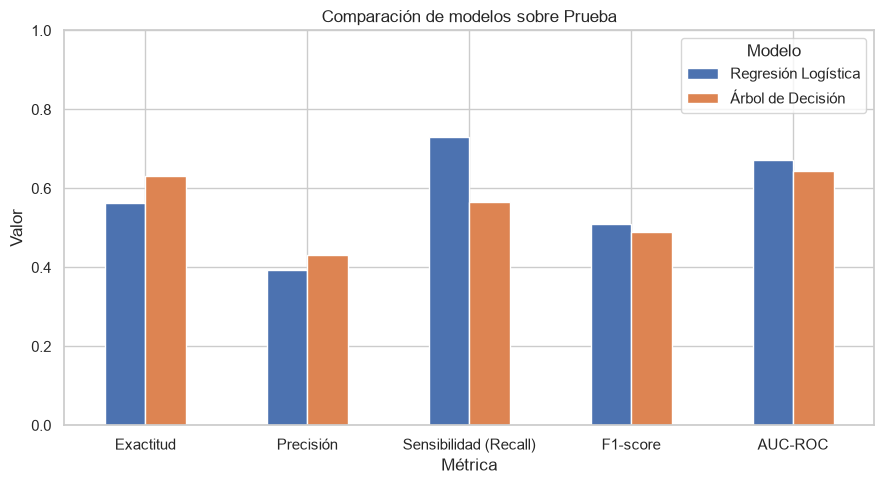

In [27]:
ax = comparacion_modelos.set_index('Métrica').plot(
    kind='bar',
    figsize=(9, 5)
)

ax.set_title('Comparación de modelos sobre Prueba')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Modelo')

plt.tight_layout()
plt.show()

In [28]:
print("RESUMEN EN LENGUAJE SIMPLE")
print("---------------------------")

print(
    f"• El Árbol de Decisión detecta "
    f"{sensibilidad_arbol:.1%} de los abandonos reales."
)

print(
    f"• Cuando el Árbol genera una alerta, "
    f"{precision_arbol:.1%} de esas alertas corresponden realmente a abandono."
)

print(
    f"• De {total_abandonos_reales} abandonos reales del conjunto de prueba, "
    f"detectó {tp} y no detectó {fn}."
)

print(
    f"• La Regresión Logística alcanza una Sensibilidad de "
    f"{metricas_logit['Sensibilidad']:.1%}."
)

diferencia_sensibilidad = sensibilidad_arbol - metricas_logit['Sensibilidad']

if diferencia_sensibilidad > 0:
    print(
        f"• El Árbol detecta {diferencia_sensibilidad * 100:.2f} puntos porcentuales "
        f"más de abandonos que la Regresión Logística."
    )
else:
    print(
        f"• La Regresión Logística detecta {-diferencia_sensibilidad * 100:.2f} "
        f"puntos porcentuales más de abandonos que el Árbol."
    )

if f1_arbol > metricas_logit['F1-score']:
    print("• El Árbol presenta el F1-score más alto entre los dos modelos.")
else:
    print("• La Regresión Logística presenta el F1-score más alto entre los dos modelos.")

if auc_arbol > metricas_logit['AUC-ROC']:
    print("• El Árbol presenta el AUC-ROC más alto entre los dos modelos.")
else:
    print("• La Regresión Logística presenta el AUC-ROC más alto entre los dos modelos.")

RESUMEN EN LENGUAJE SIMPLE
---------------------------
• El Árbol de Decisión detecta 56.4% de los abandonos reales.
• Cuando el Árbol genera una alerta, 43.0% de esas alertas corresponden realmente a abandono.
• De 1524 abandonos reales del conjunto de prueba, detectó 860 y no detectó 664.
• La Regresión Logística alcanza una Sensibilidad de 73.1%.
• La Regresión Logística detecta 16.67 puntos porcentuales más de abandonos que el Árbol.
• La Regresión Logística presenta el F1-score más alto entre los dos modelos.
• La Regresión Logística presenta el AUC-ROC más alto entre los dos modelos.


## 13. Conclusiones

### ¿Qué aprendimos del Árbol de Decisión?

El Árbol de Decisión permite representar el problema como una secuencia de preguntas.
Las primeras reglas muestran cómo características como los **créditos matriculados**,
el **módulo cursado**, la **presentación** y la **educación previa** ayudan a separar
grupos con distinta proporción de abandono.

Esto representa **asociación predictiva**, no causalidad.

### Configuración del modelo

La configuración seleccionada mediante validación cruzada fue:

- **Profundidad máxima:** 10 niveles.
- **Mínimo de registros por hoja:** 20.
- **Mínimo de registros para dividir un nodo:** 2.

### Punto de corte

El punto de corte se determina mediante el **Índice de Youden**, buscando un equilibrio
entre **Sensibilidad** y **Especificidad**.

El cálculo se realiza con el conjunto de **Validación** y posteriormente se aplica,
sin modificarlo, al conjunto de **Prueba**.

### Interpretación práctica

La **Sensibilidad** responde:

> De todos los abandonos reales, ¿cuántos detectó el modelo?

La **Especificidad** responde:

> De todos los casos que realmente no abandonaron, ¿cuántos identificó correctamente?

La **Precisión** responde:

> De todas las alertas generadas, ¿cuántas correspondían realmente a abandono?

El **F1-score** resume el equilibrio entre Precisión y Sensibilidad.

### Comparación con Regresión Logística

Los dos modelos aportan perspectivas diferentes:

- La **Regresión Logística** ofrece una interpretación estadística de la relación entre variables y probabilidad.
- El **Árbol de Decisión** permite explicar las primeras decisiones mediante preguntas y rutas comprensibles.

La evaluación final debe considerar conjuntamente **Sensibilidad, Especificidad,
Precisión, F1-score, AUC-ROC, falsas alertas y abandonos no detectados**.

Los resultados deben contrastarse con los criterios técnicos definidos por el proyecto:

- **Sensibilidad ≥ 0.75**
- **F1-score ≥ 0.70**

Si alguno de estos criterios no se alcanza, el resultado sigue siendo útil como evidencia
para justificar nuevas iteraciones del proceso de minería de datos.